In [2]:
import pandas as pd,numpy as np
import matplotlib.pyplot as plt,seaborn as sns
import kagglehub

In [3]:
path = kagglehub.dataset_download("yasserh/loan-default-dataset")

df = pd.read_csv(path + "/Loan_Default.csv", encoding="latin1")

df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [5]:
df = df.drop(['year','ID'],axis=1)


In [6]:
CatCols = df.select_dtypes(object).columns

In [7]:
NumCols = df.select_dtypes(exclude=object).columns

In [8]:
df[NumCols]

,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
0,116500,NaN,NaN,NaN,360.0,118000.0,1740.0,758,98.728814,1,45.0
1,206500,NaN,NaN,NaN,360.0,NaN,4980.0,552,NaN,1,NaN
2,406500,4.560,0.2000,595.00,360.0,508000.0,9480.0,834,80.019685,0,46.0
3,456500,4.250,0.6810,NaN,360.0,658000.0,11880.0,587,69.376900,0,42.0
4,696500,4.000,0.3042,0.00,360.0,758000.0,10440.0,602,91.886544,0,39.0
...,...,...,...,...,...,...,...,...,...,...,...
148665,436500,3.125,0.2571,9960.00,180.0,608000.0,7860.0,659,71.792763,0,48.0
148666,586500,5.190,0.8544,0.00,360.0,788000.0,7140.0,569,74.428934,0,15.0
148667,446500,3.125,0.0816,1226.64,180.0,728000.0,6900.0,702,61.332418,0,49.0
148668,196500,3.500,0.5824,4323.33,180.0,278000.0,7140.0,737,70.683453,0,29.0


In [9]:
df['Status'].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

In [10]:
df.shape

(148670, 32)

In [11]:
df.isnull().sum()

loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_application      200
LTV                          15098
Region              

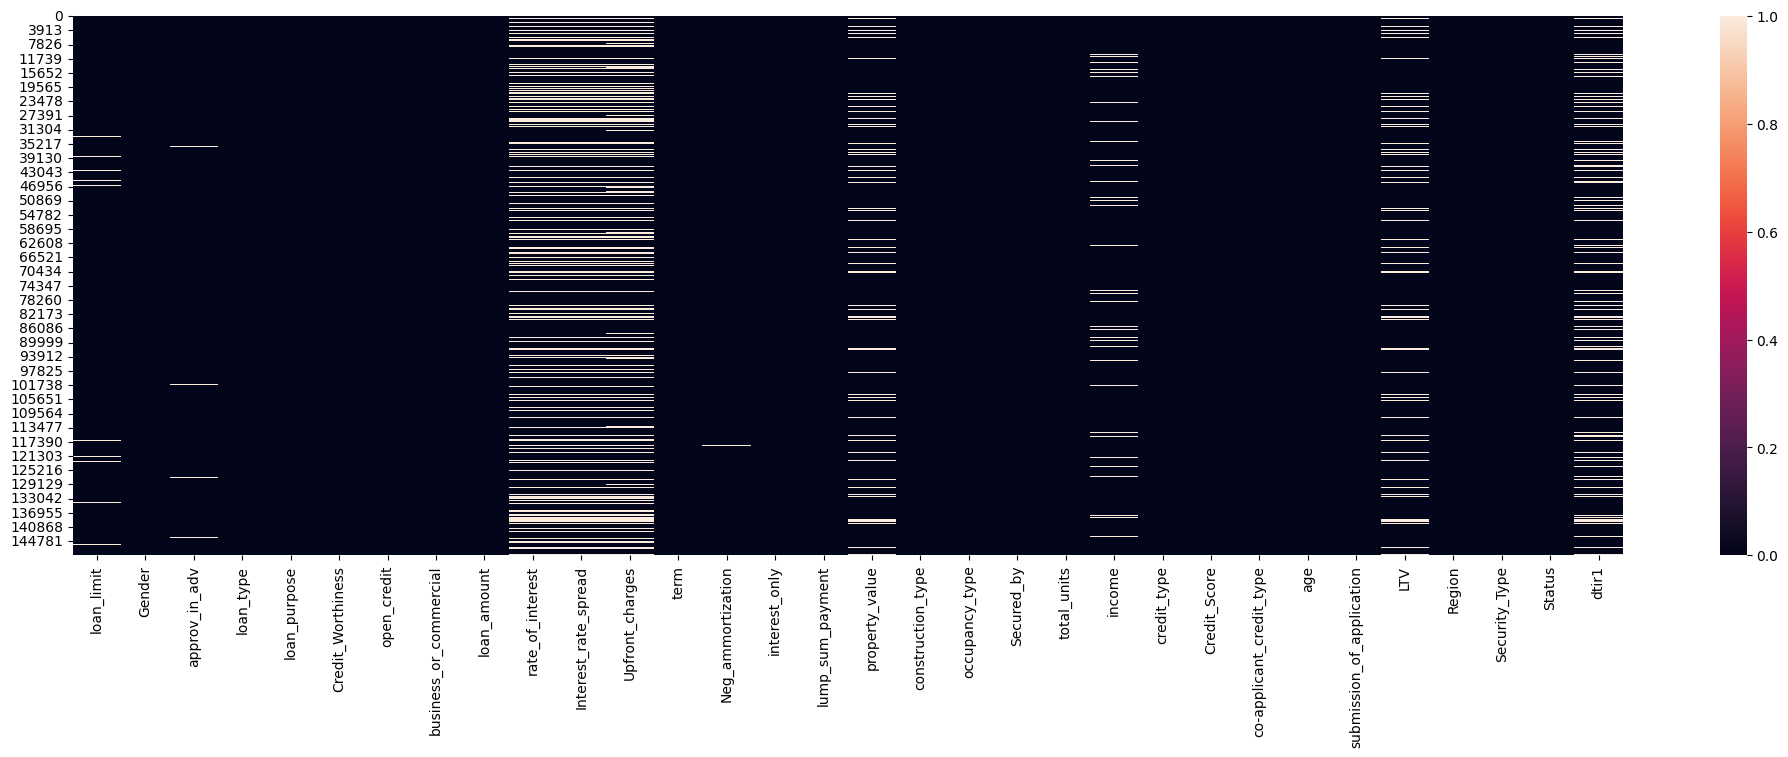

In [12]:
plt.figure(figsize=(25,7))
sns.heatmap(df.isnull())
plt.show()

## Categorical Columns details

In [13]:
for col in CatCols:
    print("*"*28)
    print(col)
    print(df[col].unique())

****************************
loan_limit
['cf' nan 'ncf']
****************************
Gender
['Sex Not Available' 'Male' 'Joint' 'Female']
****************************
approv_in_adv
['nopre' 'pre' nan]
****************************
loan_type
['type1' 'type2' 'type3']
****************************
loan_purpose
['p1' 'p4' 'p3' 'p2' nan]
****************************
Credit_Worthiness
['l1' 'l2']
****************************
open_credit
['nopc' 'opc']
****************************
business_or_commercial
['nob/c' 'b/c']
****************************
Neg_ammortization
['not_neg' 'neg_amm' nan]
****************************
interest_only
['not_int' 'int_only']
****************************
lump_sum_payment
['not_lpsm' 'lpsm']
****************************
construction_type
['sb' 'mh']
****************************
occupancy_type
['pr' 'sr' 'ir']
****************************
Secured_by
['home' 'land']
****************************
total_units
['1U' '2U' '3U' '4U']
****************************
credit_ty

In [14]:
for col in CatCols:
    print("*"*28)
    print(df[col].value_counts())

****************************
loan_limit
cf     135348
ncf      9978
Name: count, dtype: int64
****************************
Gender
Male                 42346
Joint                41399
Sex Not Available    37659
Female               27266
Name: count, dtype: int64
****************************
approv_in_adv
nopre    124621
pre       23141
Name: count, dtype: int64
****************************
loan_type
type1    113173
type2     20762
type3     14735
Name: count, dtype: int64
****************************
loan_purpose
p3    55934
p4    54799
p1    34529
p2     3274
Name: count, dtype: int64
****************************
Credit_Worthiness
l1    142344
l2      6326
Name: count, dtype: int64
****************************
open_credit
nopc    148114
opc        556
Name: count, dtype: int64
****************************
business_or_commercial
nob/c    127908
b/c       20762
Name: count, dtype: int64
****************************
Neg_ammortization
not_neg    133420
neg_amm     15129
Name: count, dtyp

In [15]:
sns.set_theme(style="whitegrid")

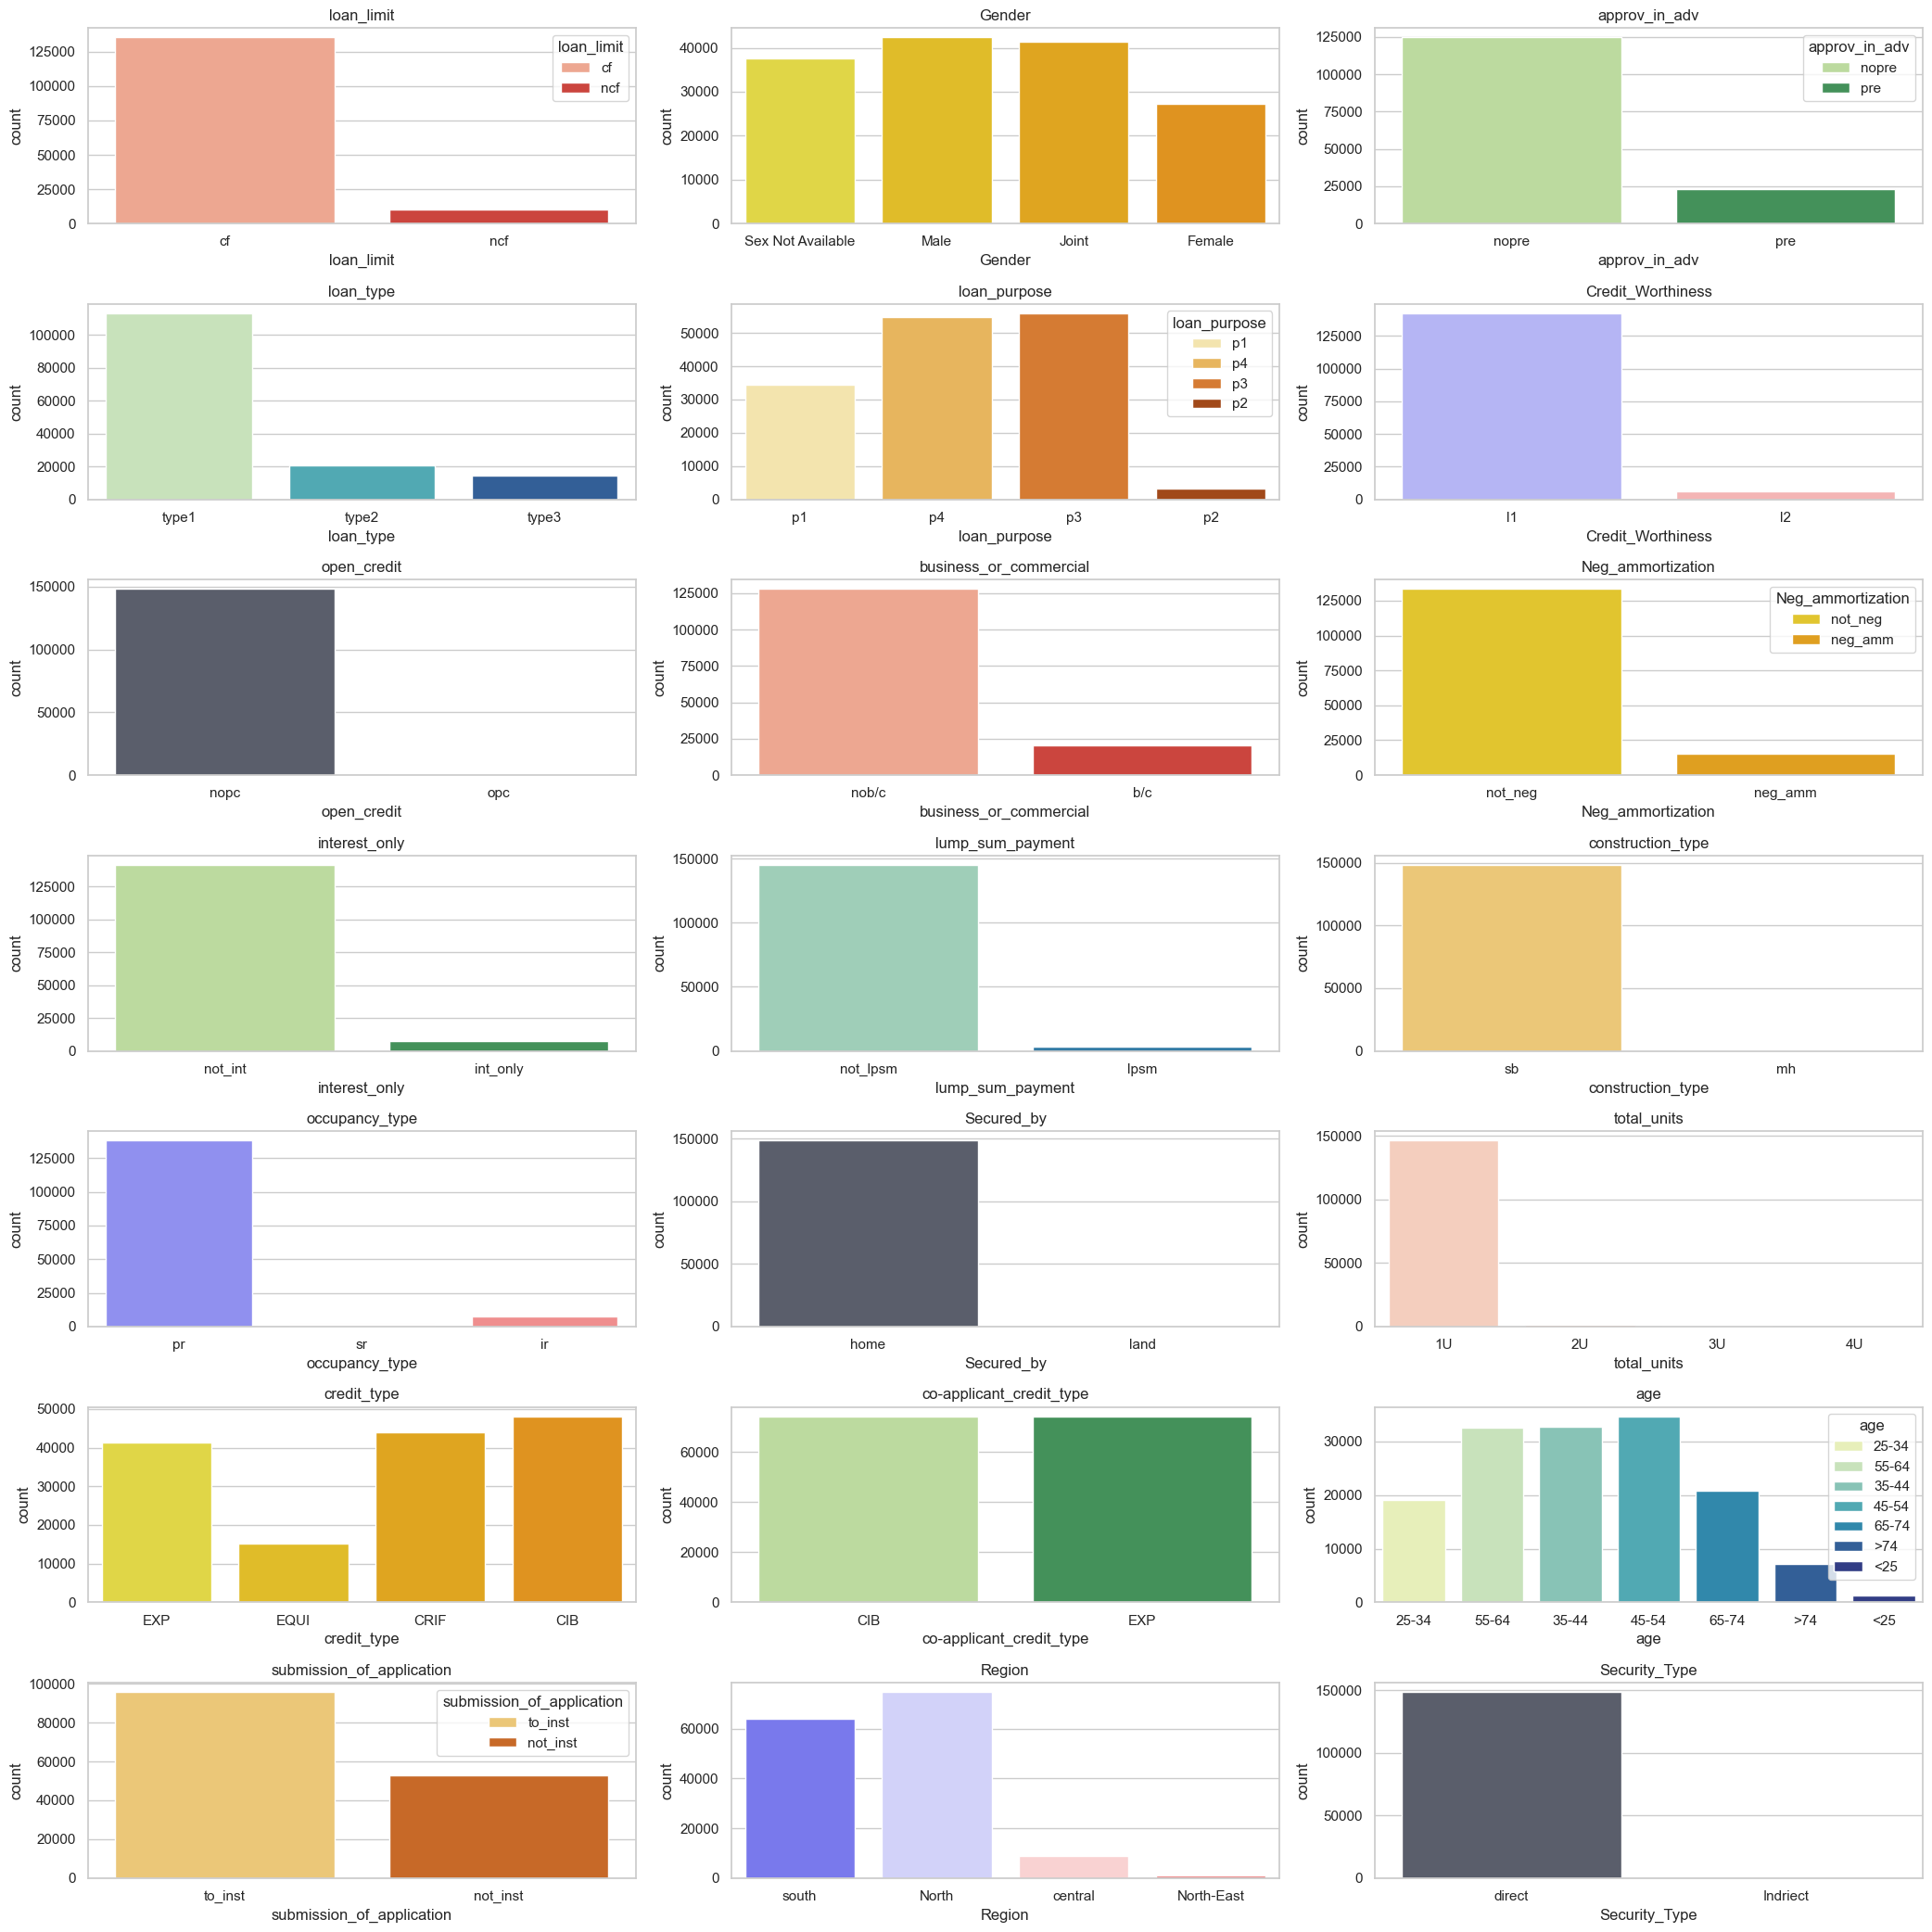

In [16]:
fig,axes = plt.subplots(7,3,figsize=(21,21))
ax = axes.flatten()
p = ['Reds','Wistia','YlGn','YlGnBu','YlOrBr','bwr','cividis']
for i,col in enumerate(CatCols):
    sns.countplot(df,x=col,hue=col,ax=ax[i],palette=p[i%7]).set_title(col)

plt.tight_layout()
plt.show()

In [17]:
df[df['Security_Type']=='Indriect']['Status']

7973      1
32312     1
34412     1
35368     1
36155     1
41151     1
44592     1
46022     1
47828     1
56153     1
59732     1
60122     1
62581     1
68927     1
82520     1
85185     1
90473     1
91255     1
104761    1
105639    1
106363    1
109160    1
109448    1
109934    1
120254    1
122468    1
123610    1
124614    1
125783    1
128515    1
140486    1
146525    1
148023    1
Name: Status, dtype: int64

### hue: Status

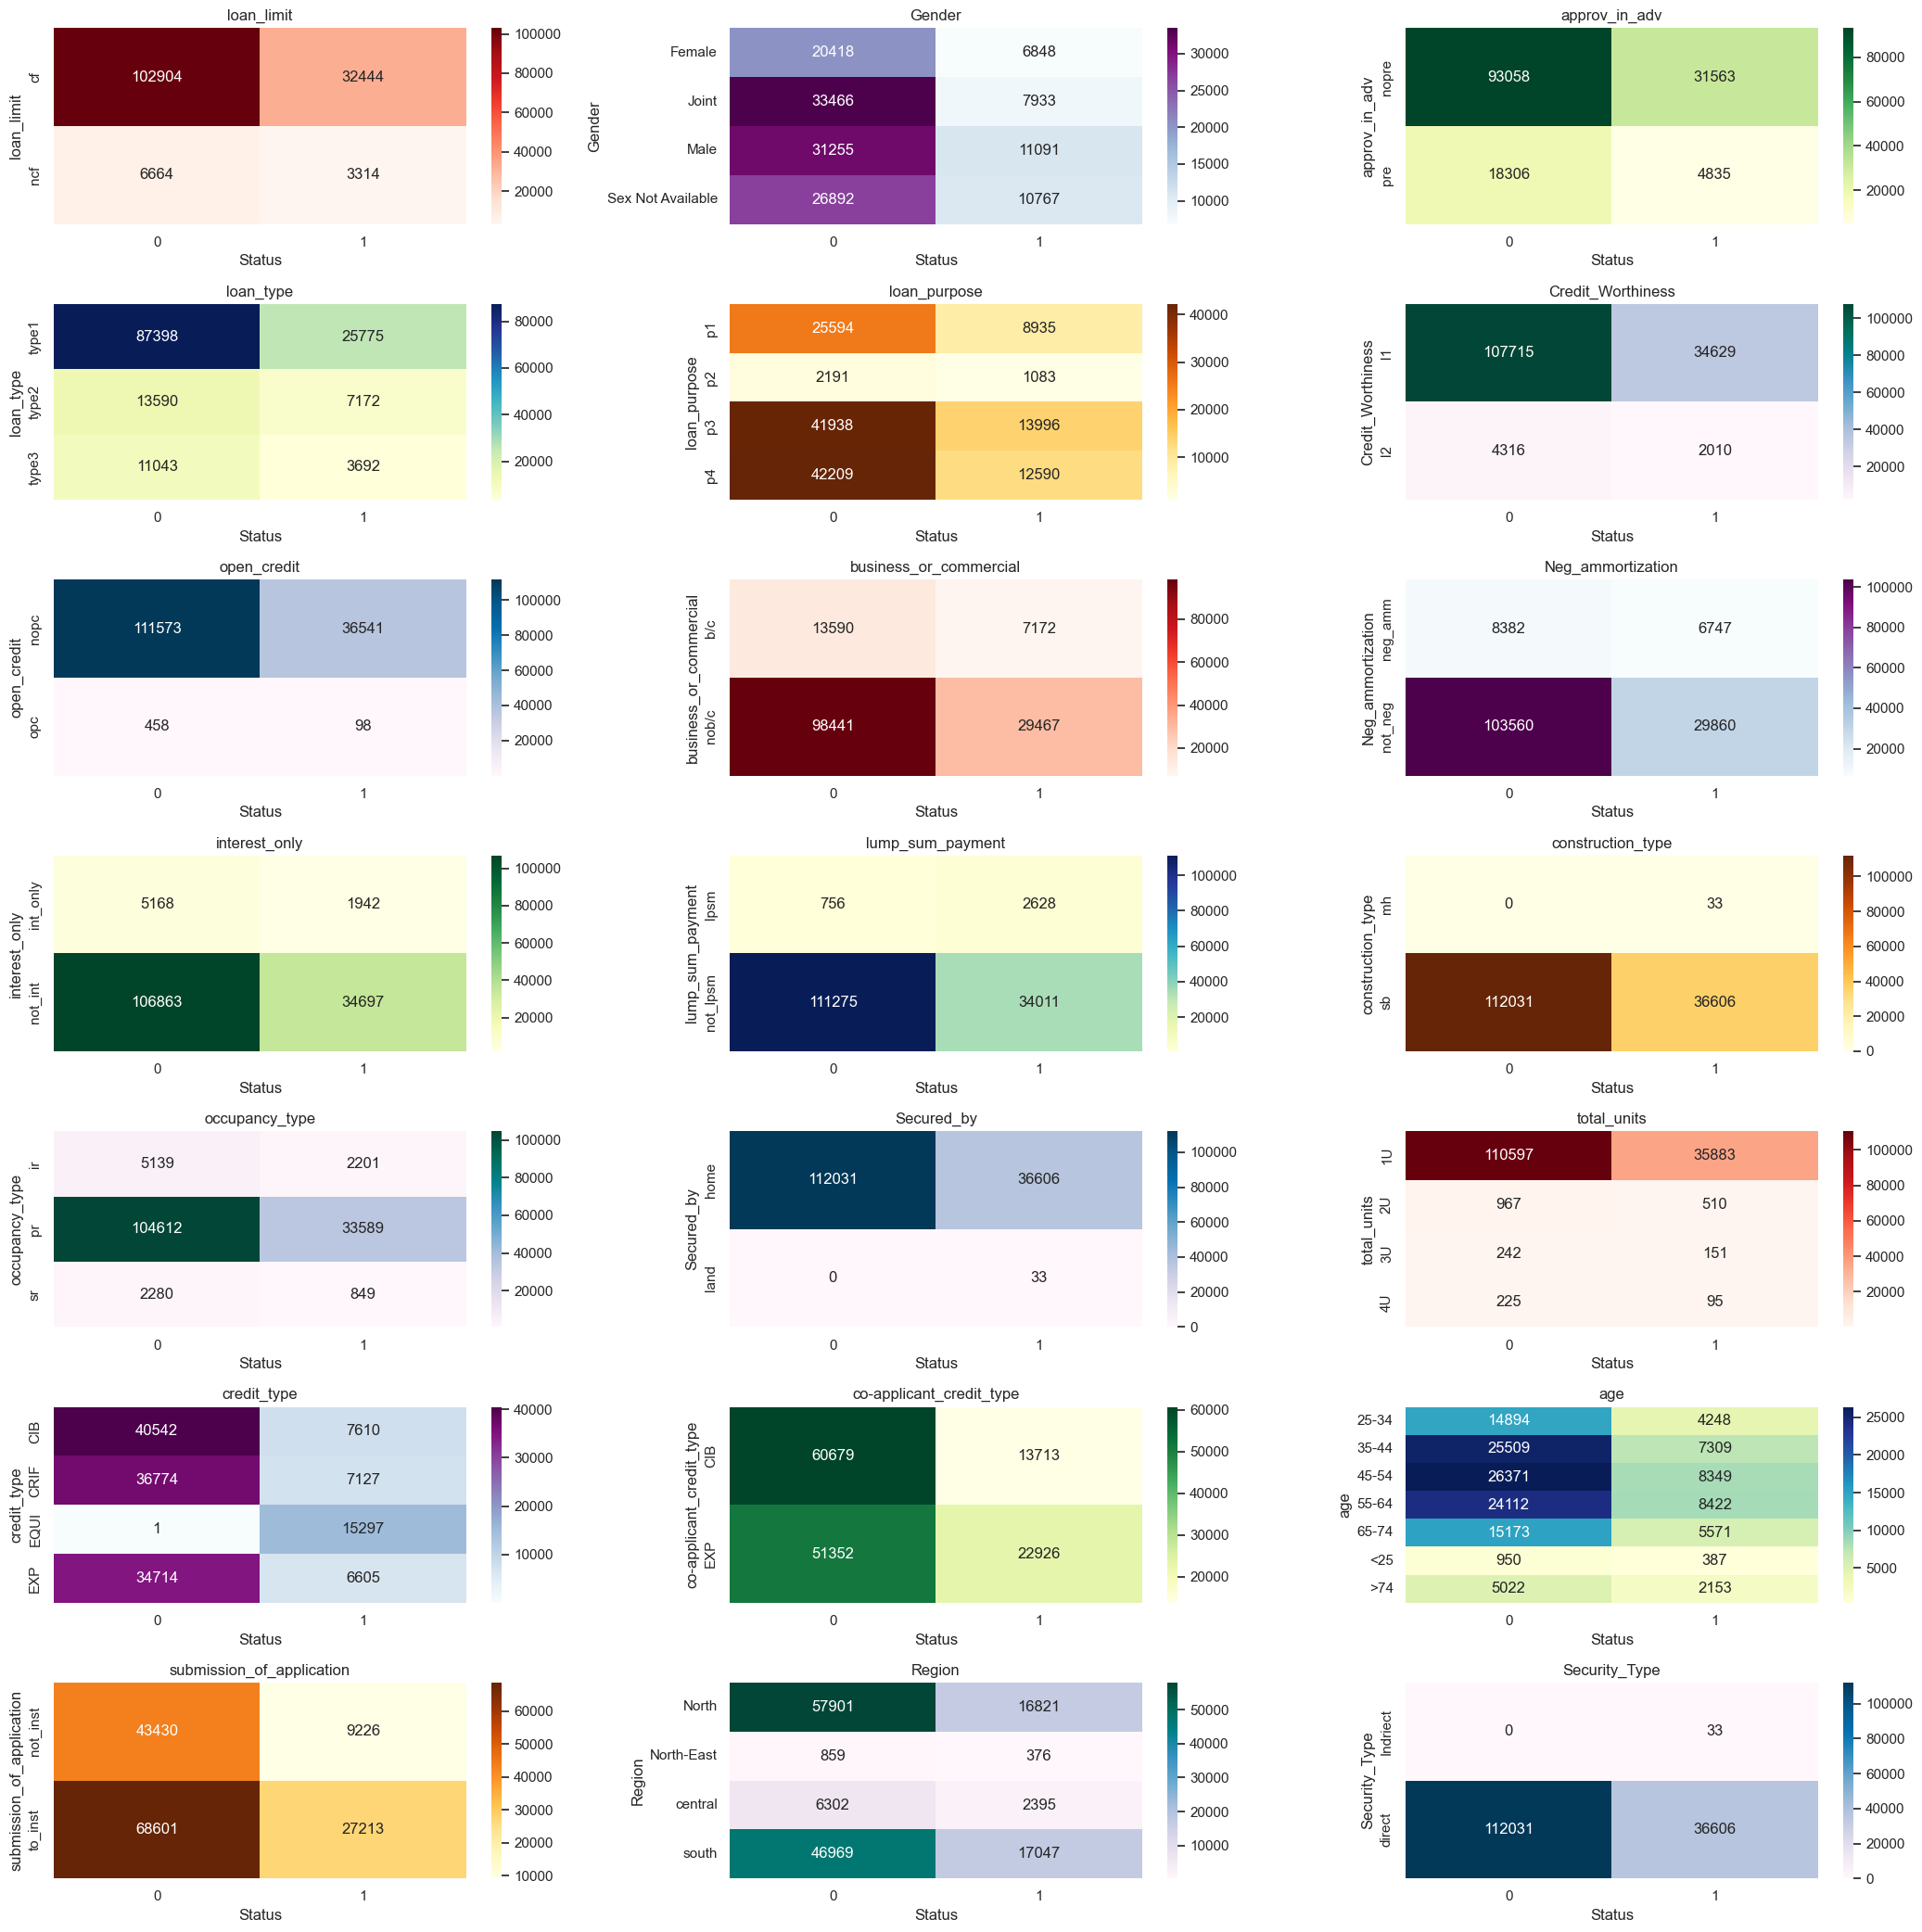

In [18]:
fig,axes = plt.subplots(7,3,figsize=(21,21))
ax = axes.flatten()
colors = ['Reds','BuPu','YlGn','YlGnBu','YlOrBr','PuBuGn','PuBu']
for i,col in enumerate(CatCols):
    sns.heatmap(pd.crosstab(columns=df['Status'],index=df[col]),annot=True,fmt="d",ax=ax[i],cmap=colors[i%7]).set_title(col)

plt.tight_layout()
plt.show()

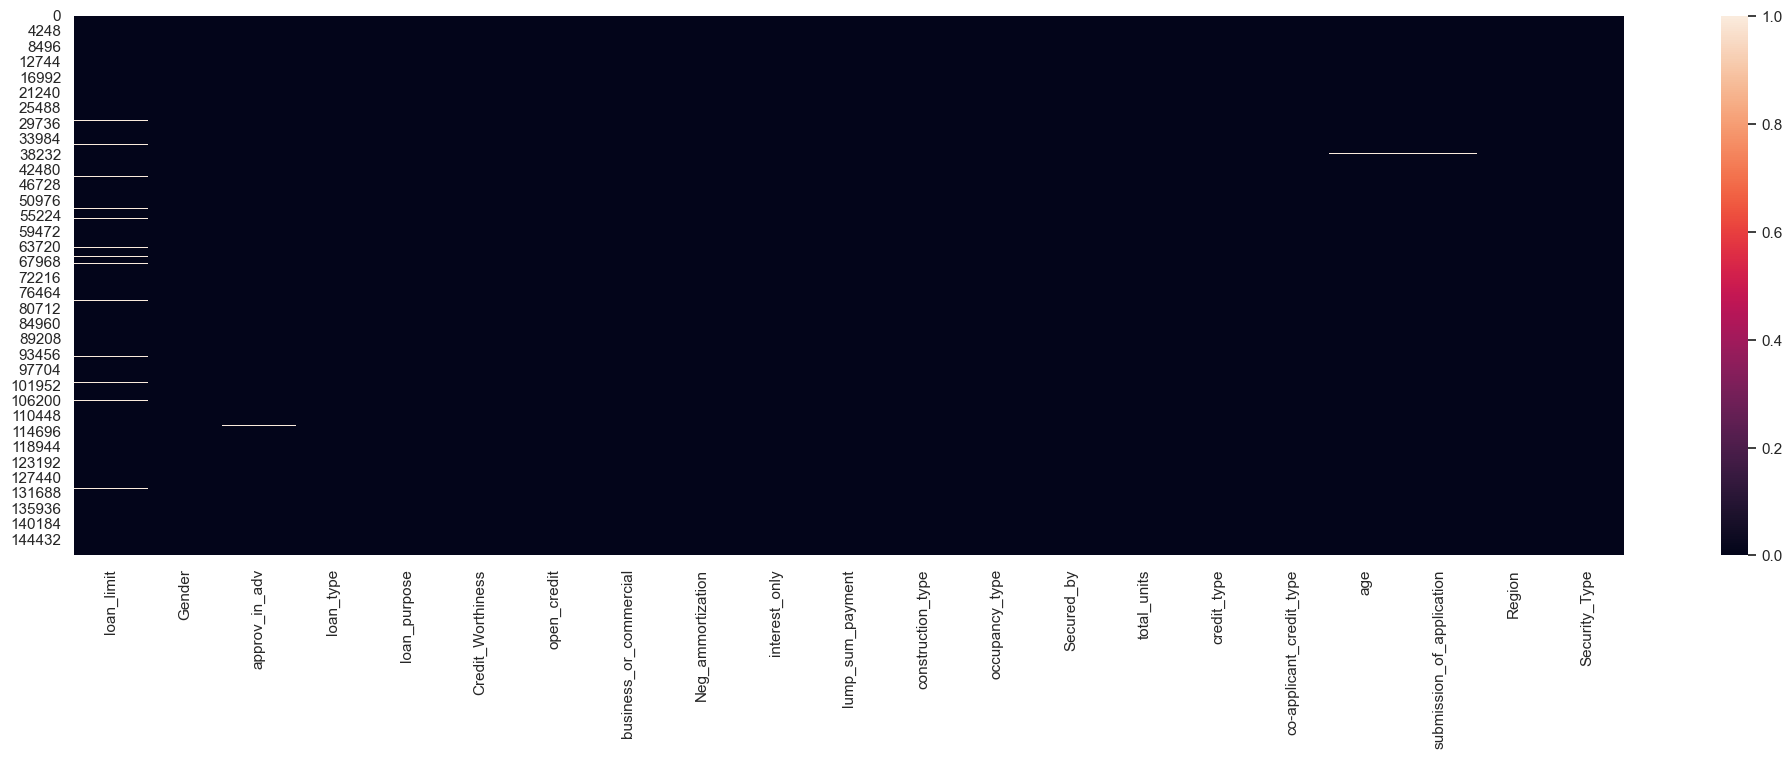

In [19]:
plt.figure(figsize=(25,7))
sns.heatmap(df[CatCols].isnull())
plt.show()

In [20]:
df.dropna()

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
2,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.560,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
4,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.000,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0
5,cf,Joint,pre,type1,p1,l1,nopc,nob/c,706500,3.990,...,EXP,864,EXP,35-44,not_inst,70.089286,North,direct,0,40.0
6,cf,Joint,pre,type1,p3,l1,nopc,nob/c,346500,4.500,...,EXP,860,EXP,55-64,to_inst,79.109589,North,direct,0,44.0
8,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,376500,4.875,...,CIB,580,EXP,55-64,to_inst,78.765690,central,direct,0,44.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,436500,3.125,...,CIB,659,EXP,55-64,to_inst,71.792763,south,direct,0,48.0
148666,cf,Male,nopre,type1,p1,l1,nopc,nob/c,586500,5.190,...,CIB,569,CIB,25-34,not_inst,74.428934,south,direct,0,15.0
148667,cf,Male,nopre,type1,p4,l1,nopc,nob/c,446500,3.125,...,CIB,702,EXP,45-54,not_inst,61.332418,North,direct,0,49.0
148668,cf,Female,nopre,type1,p4,l1,nopc,nob/c,196500,3.500,...,EXP,737,EXP,55-64,to_inst,70.683453,North,direct,0,29.0


In [21]:
df[CatCols].isnull().sum()

loan_limit                   3344
Gender                          0
approv_in_adv                 908
loan_type                       0
loan_purpose                  134
Credit_Worthiness               0
open_credit                     0
business_or_commercial          0
Neg_ammortization             121
interest_only                   0
lump_sum_payment                0
construction_type               0
occupancy_type                  0
Secured_by                      0
total_units                     0
credit_type                     0
co-applicant_credit_type        0
age                           200
submission_of_application     200
Region                          0
Security_Type                   0
dtype: int64

## Numeric Columns details

In [22]:
pd.set_option('display.float_format', '{:.2f}'.format)
df[NumCols].describe()

,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.00,112231.00,112031.00,109028.00,148629.00,133572.00,139520.00,148670.00,133572.00,148670.00,124549.00
mean,331117.74,4.05,0.44,3225.00,335.14,497893.47,6957.34,699.79,72.75,0.25,37.73
std,183909.31,0.56,0.51,3251.12,58.41,359935.32,6496.59,115.88,39.97,0.43,10.55
min,16500.00,0.00,-3.64,0.00,96.00,8000.00,0.00,500.00,0.97,0.00,5.00
25%,196500.00,3.62,0.08,581.49,360.00,268000.00,3720.00,599.00,60.47,0.00,31.00
50%,296500.00,3.99,0.39,2596.45,360.00,418000.00,5760.00,699.00,75.14,0.00,39.00
75%,436500.00,4.38,0.78,4812.50,360.00,628000.00,8520.00,800.00,86.18,0.00,45.00
max,3576500.00,8.00,3.36,60000.00,360.00,16508000.00,578580.00,900.00,7831.25,1.00,61.00


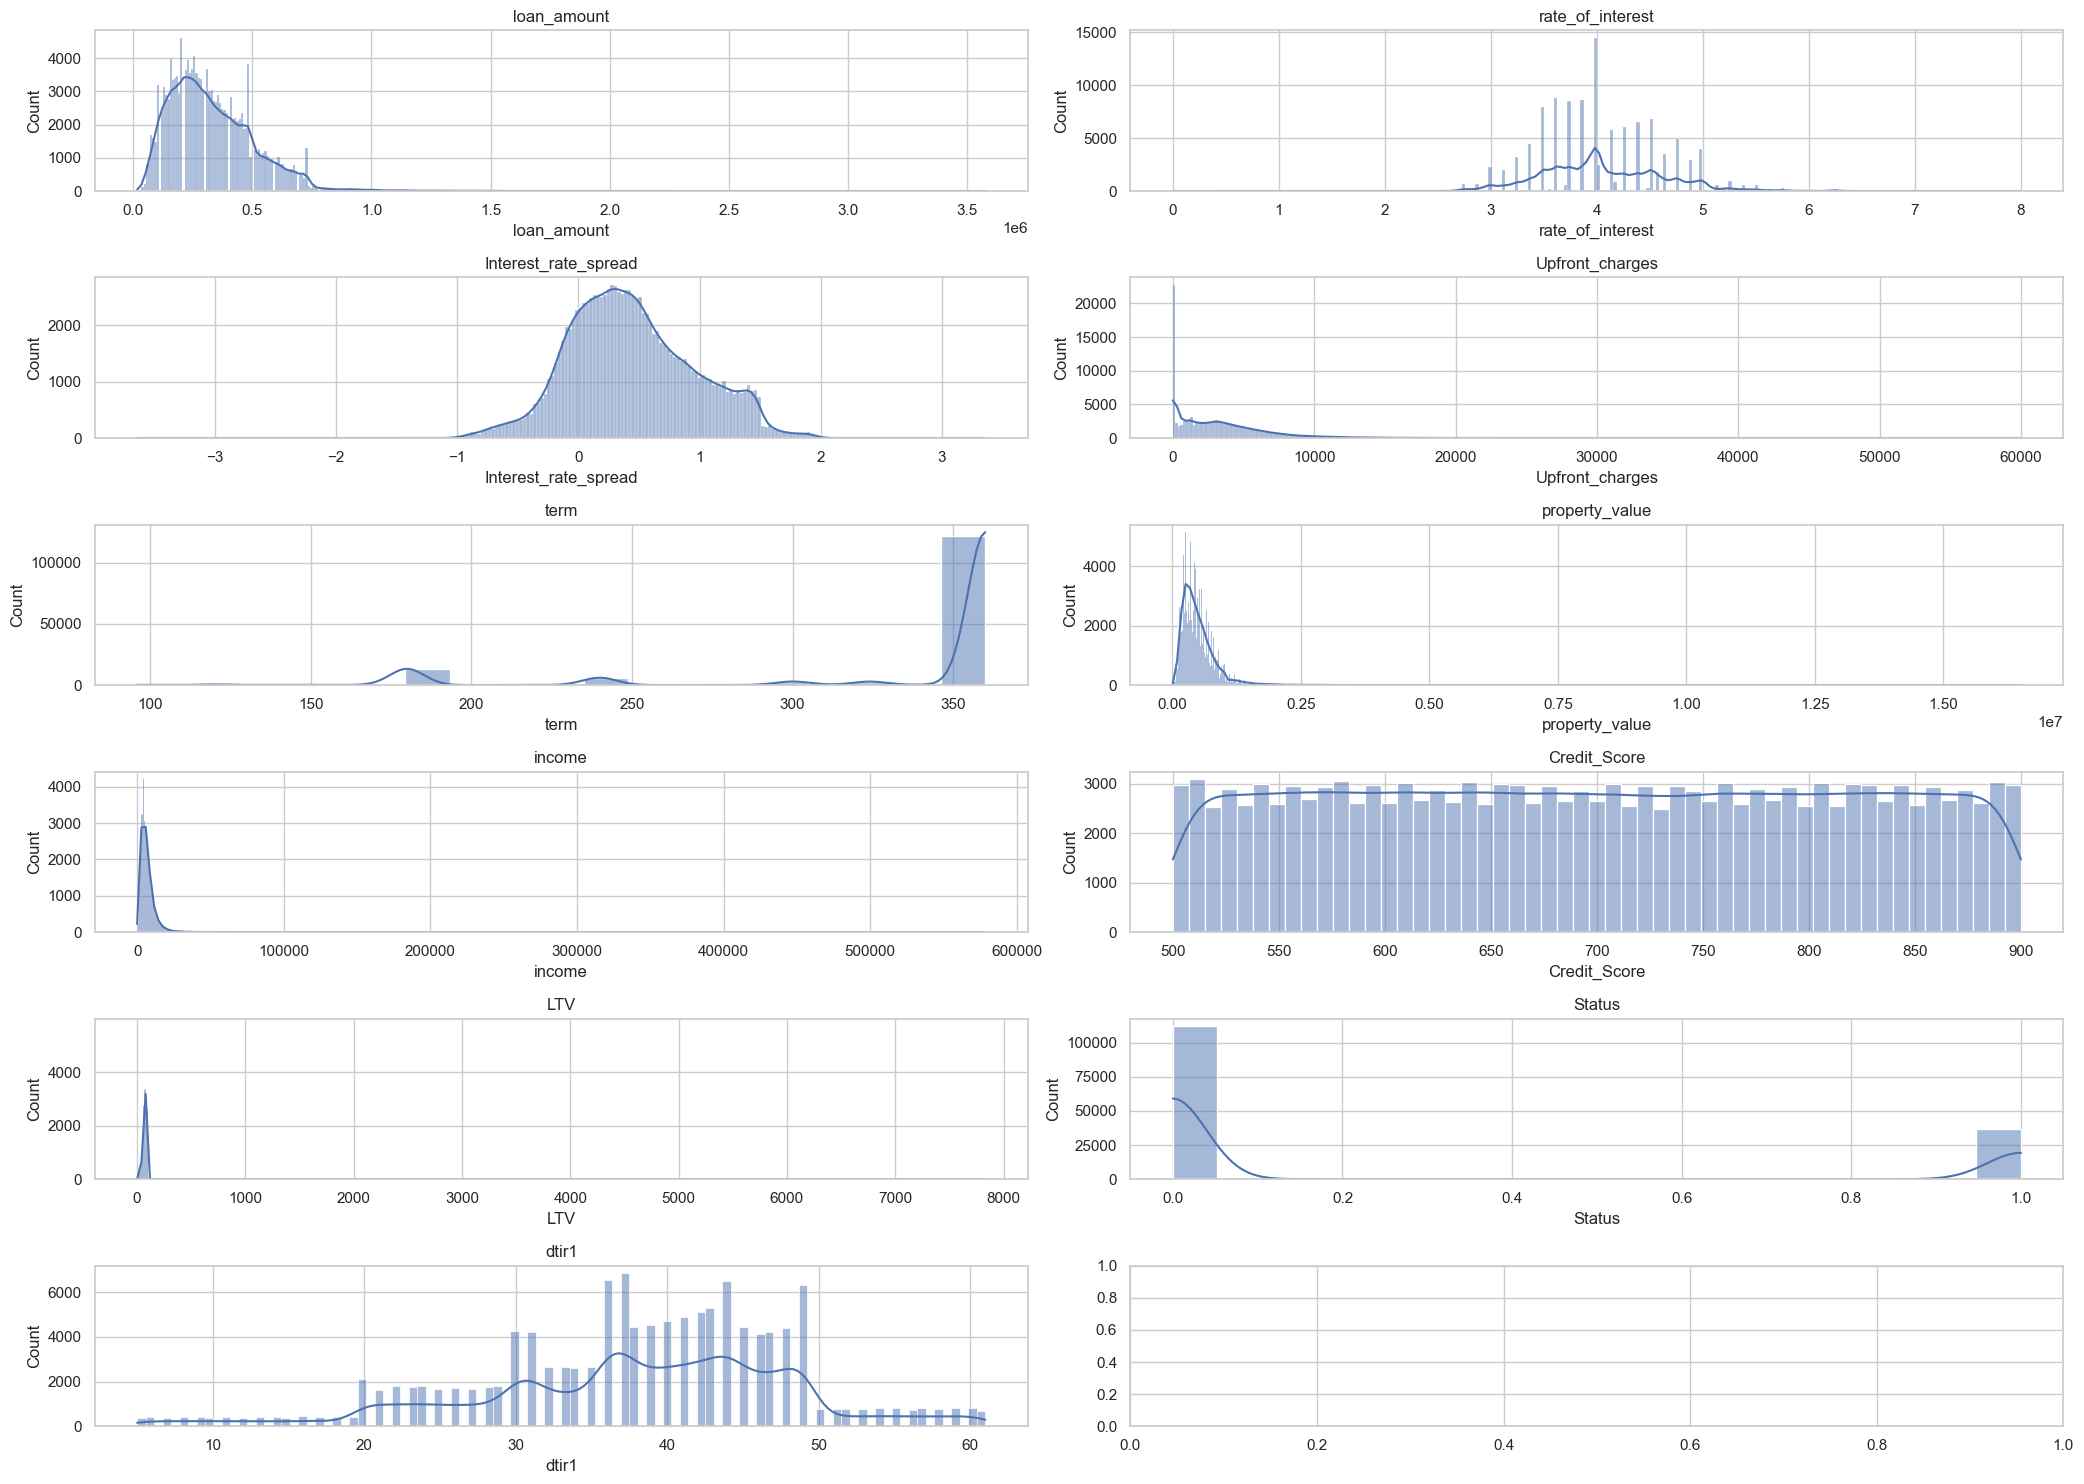

In [23]:
fig2,axes2 = plt.subplots(6,2,figsize=(21,15))
ax2 = axes2.flatten()

for i,col in enumerate(NumCols):
    sns.histplot(df,kde=True,x=col,ax=ax2[i]).set_title(col)

plt.tight_layout()
plt.show()

C:\Users\vivek\AppData\Local\Temp\ipykernel_2240\2484434157.py:7: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
D:\project 4\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


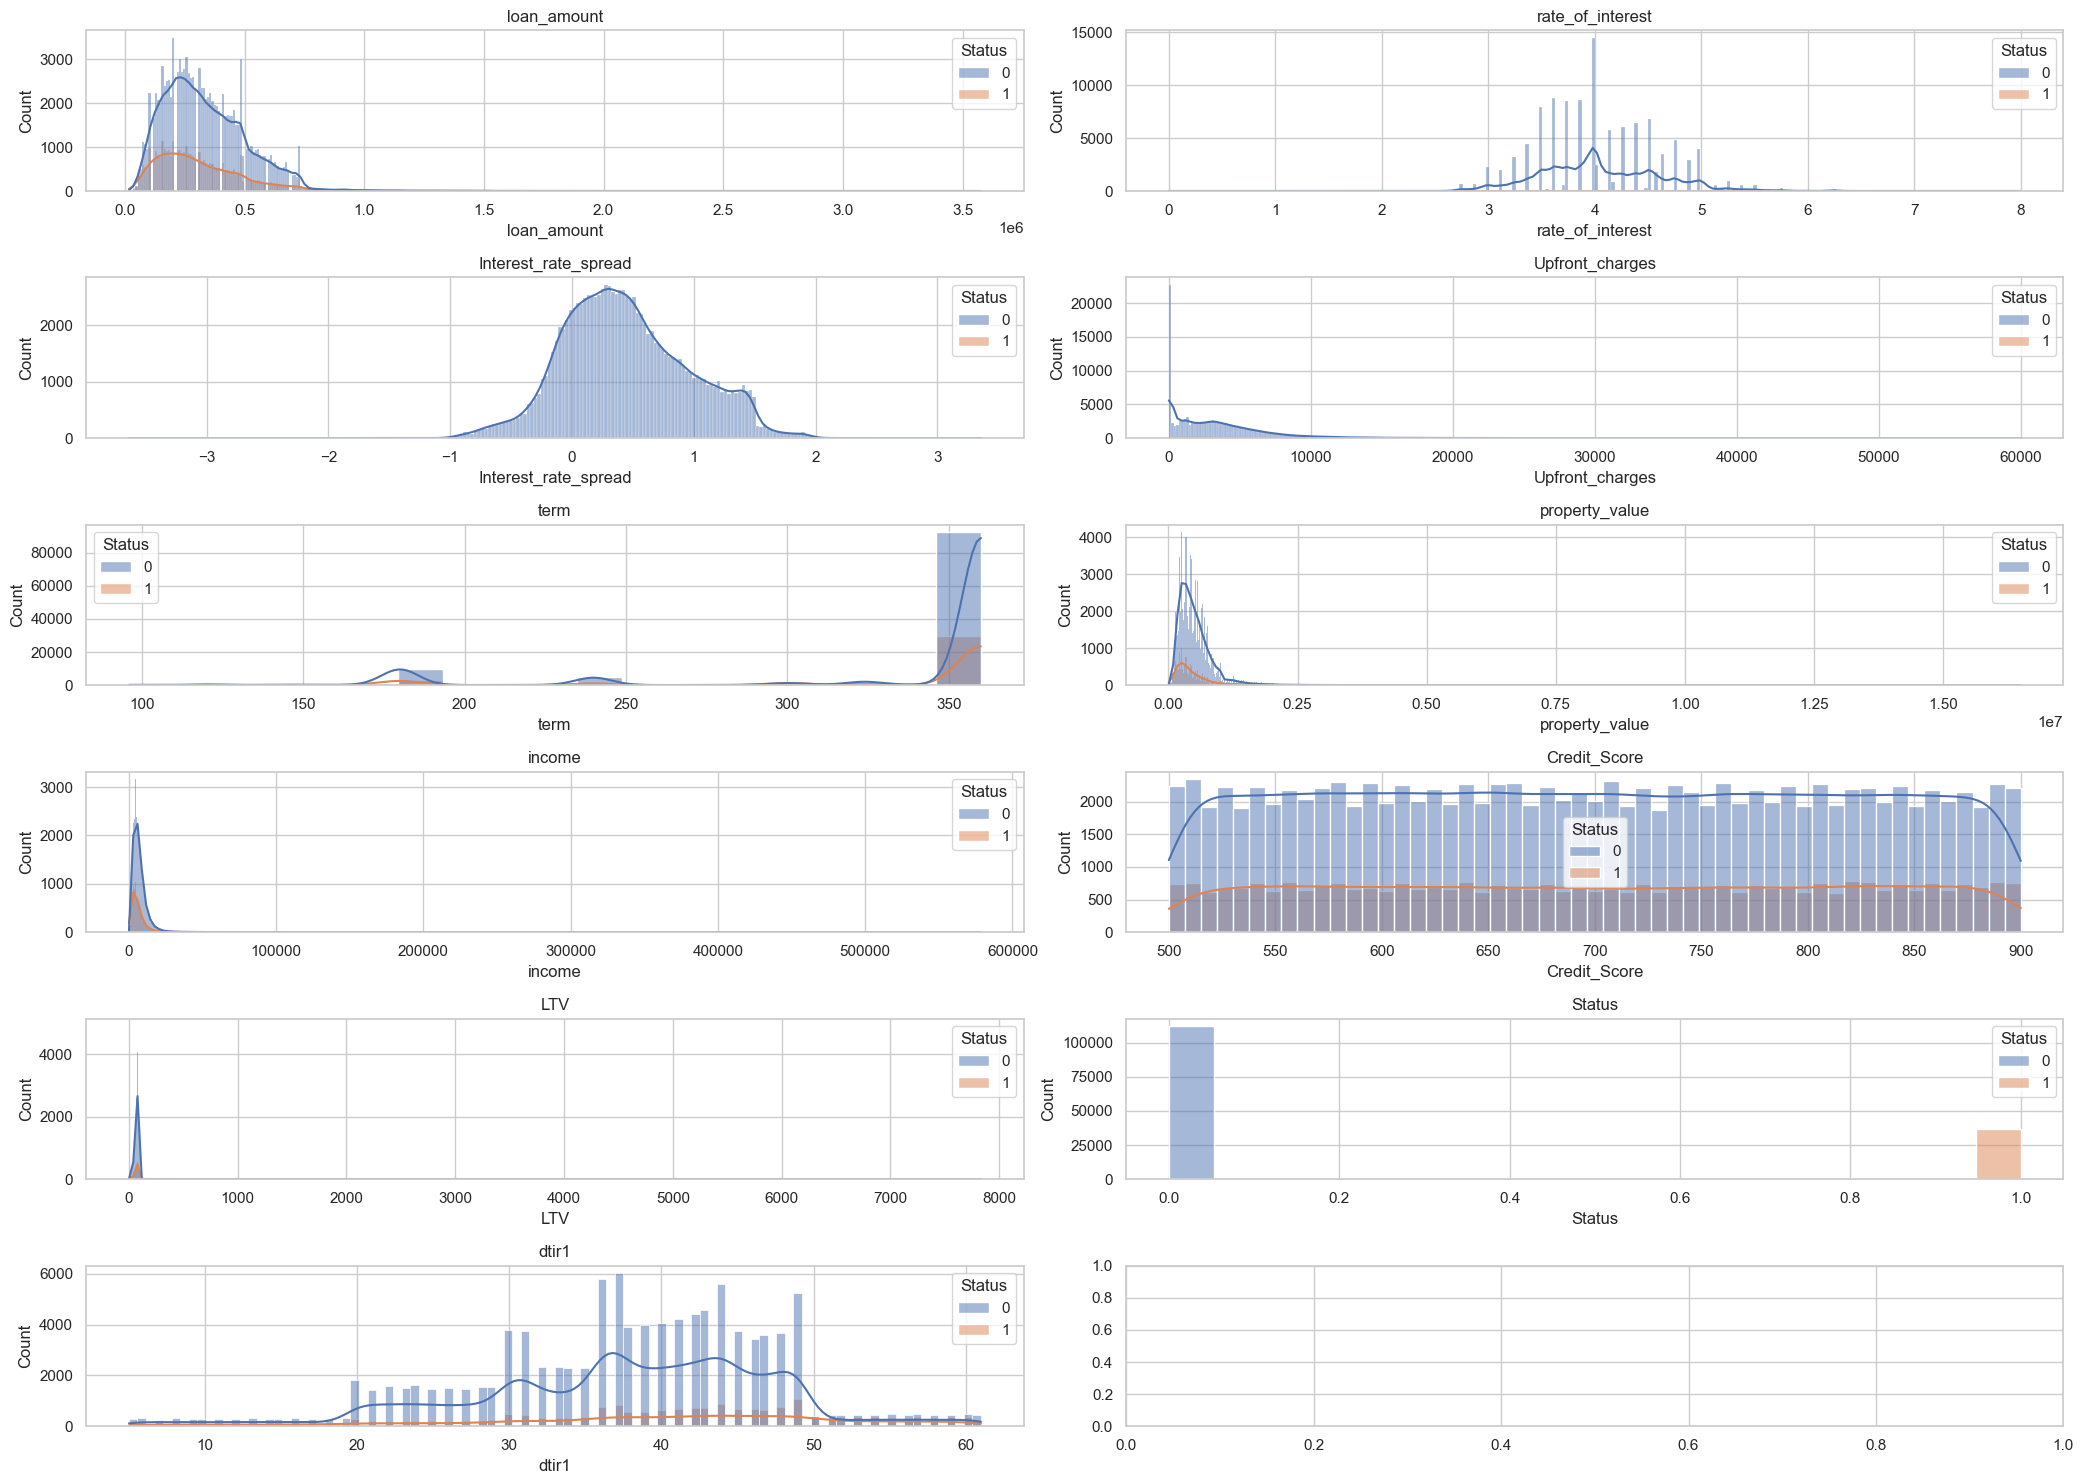

In [24]:
fig2,axes2 = plt.subplots(6,2,figsize=(21,15))
ax2 = axes2.flatten()

for i,col in enumerate(NumCols):
    sns.histplot(df,kde=True,x=col,ax=ax2[i],hue='Status').set_title(col)

plt.tight_layout()
plt.show()

In [25]:
log_cols = ['LTV','property_value','Upfront_charges','loan_amount','income']

In [26]:
logDF= np.log1p(df[log_cols])
logDF['Status'] = df['Status']

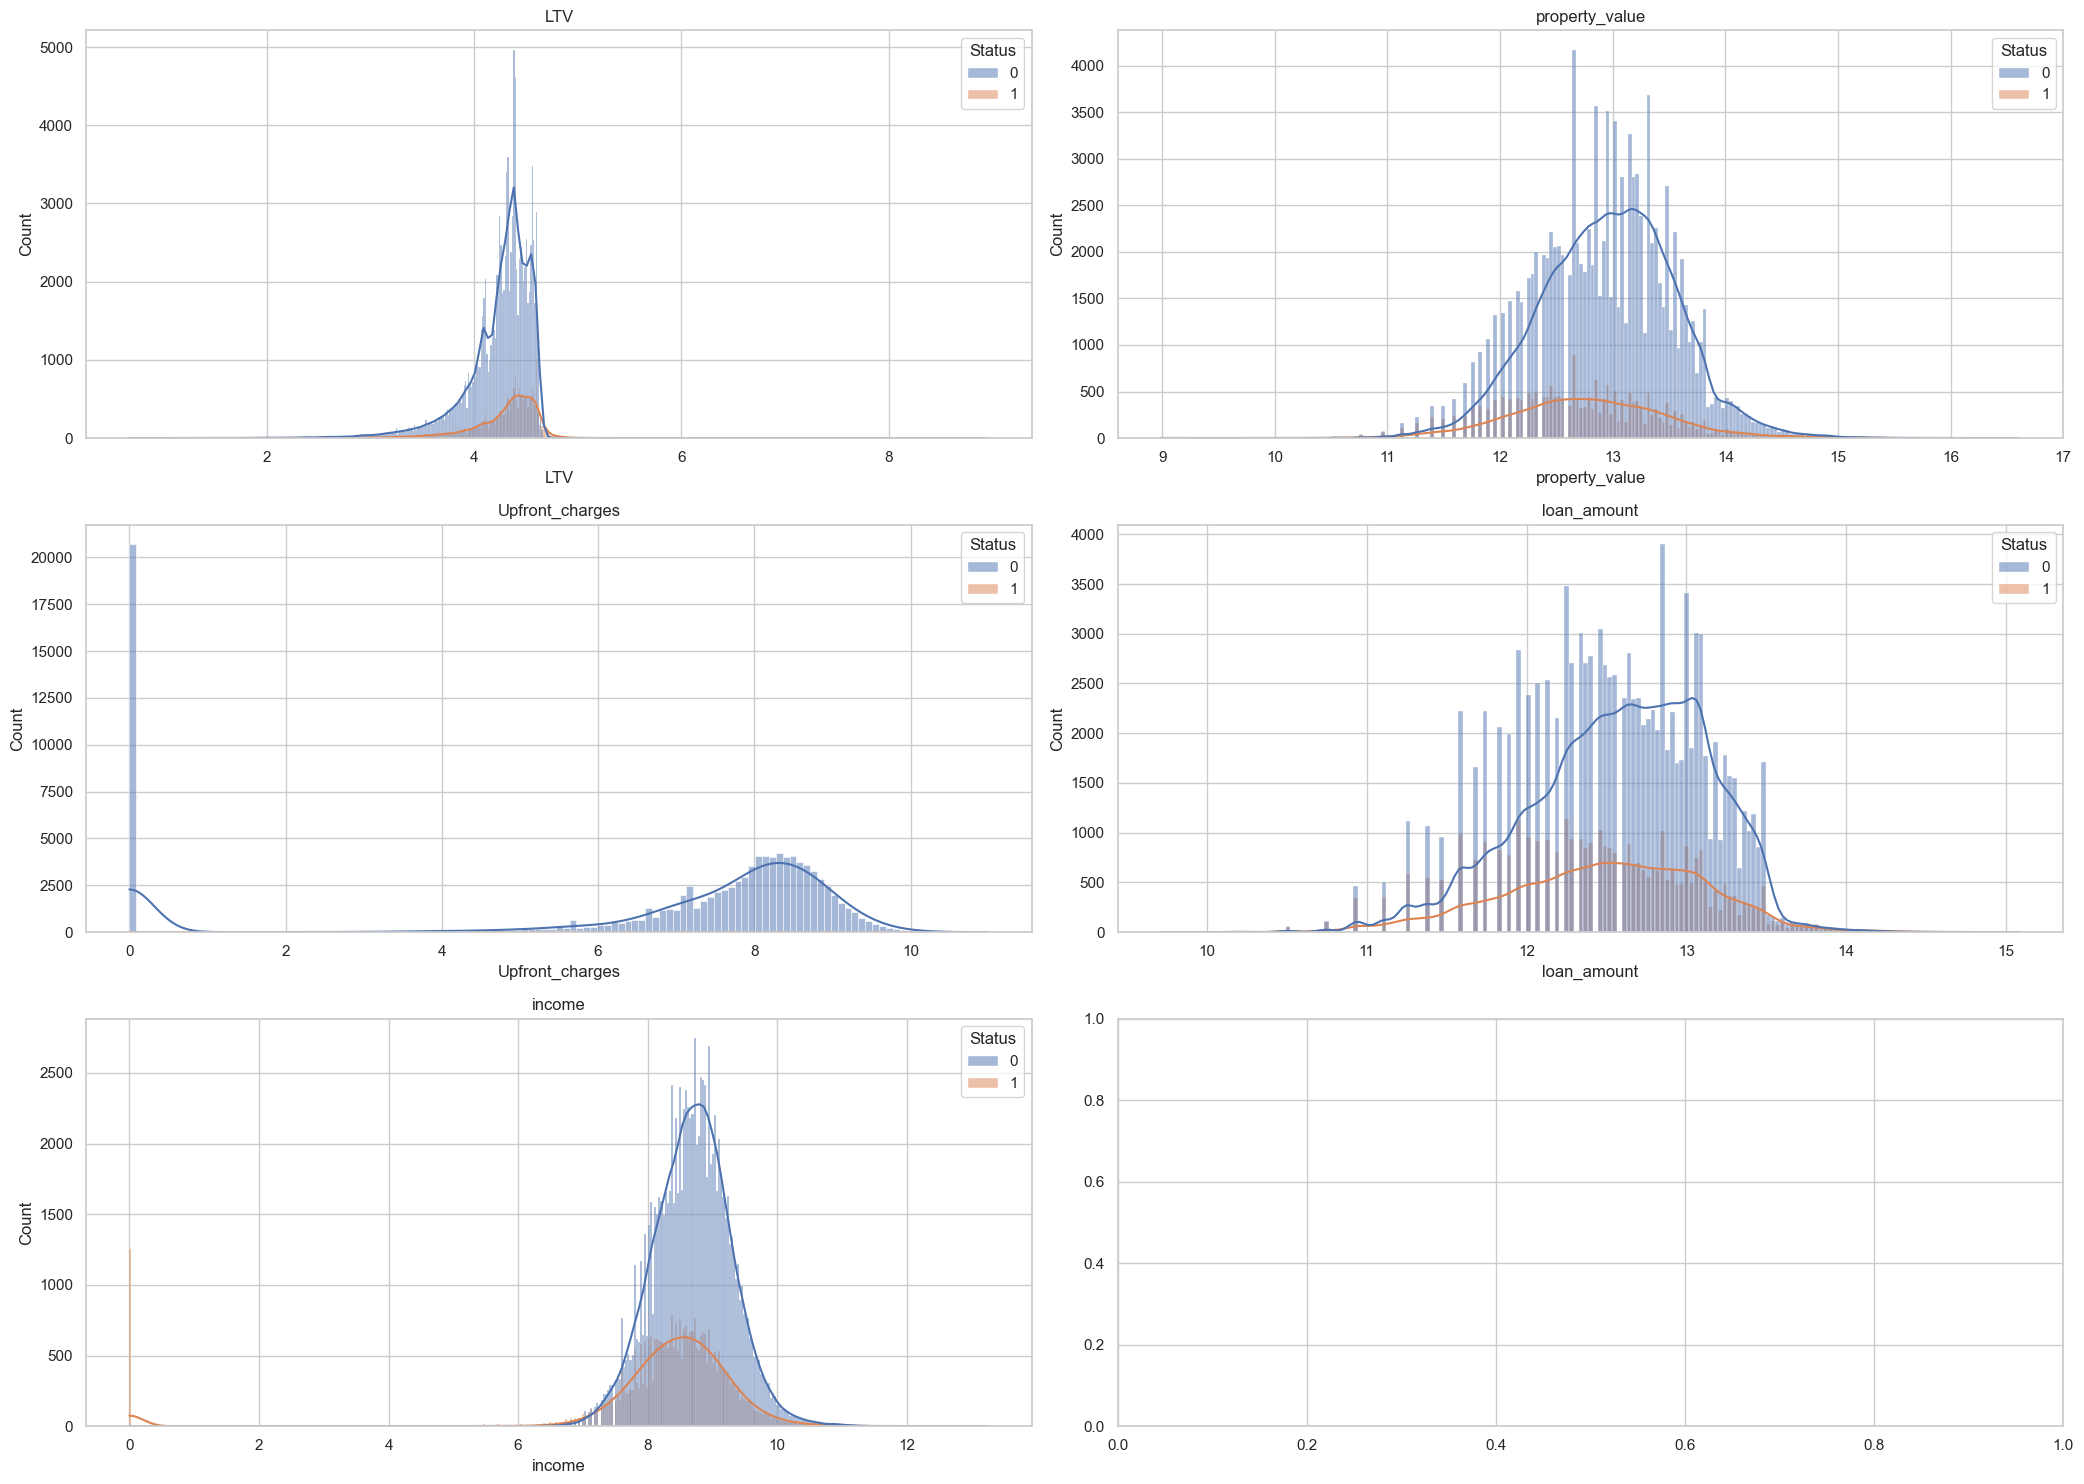

In [27]:
fig2,axes2 = plt.subplots(3,2,figsize=(21,15))
ax2 = axes2.flatten()

for i,col in enumerate(log_cols):
    sns.histplot(logDF,kde=True,x=col,ax=ax2[i],hue='Status').set_title(col)

plt.tight_layout()
plt.show()

In [28]:
df[NumCols].isnull().sum()

loan_amount                 0
rate_of_interest        36439
Interest_rate_spread    36639
Upfront_charges         39642
term                       41
property_value          15098
income                   9150
Credit_Score                0
LTV                     15098
Status                      0
dtir1                   24121
dtype: int64

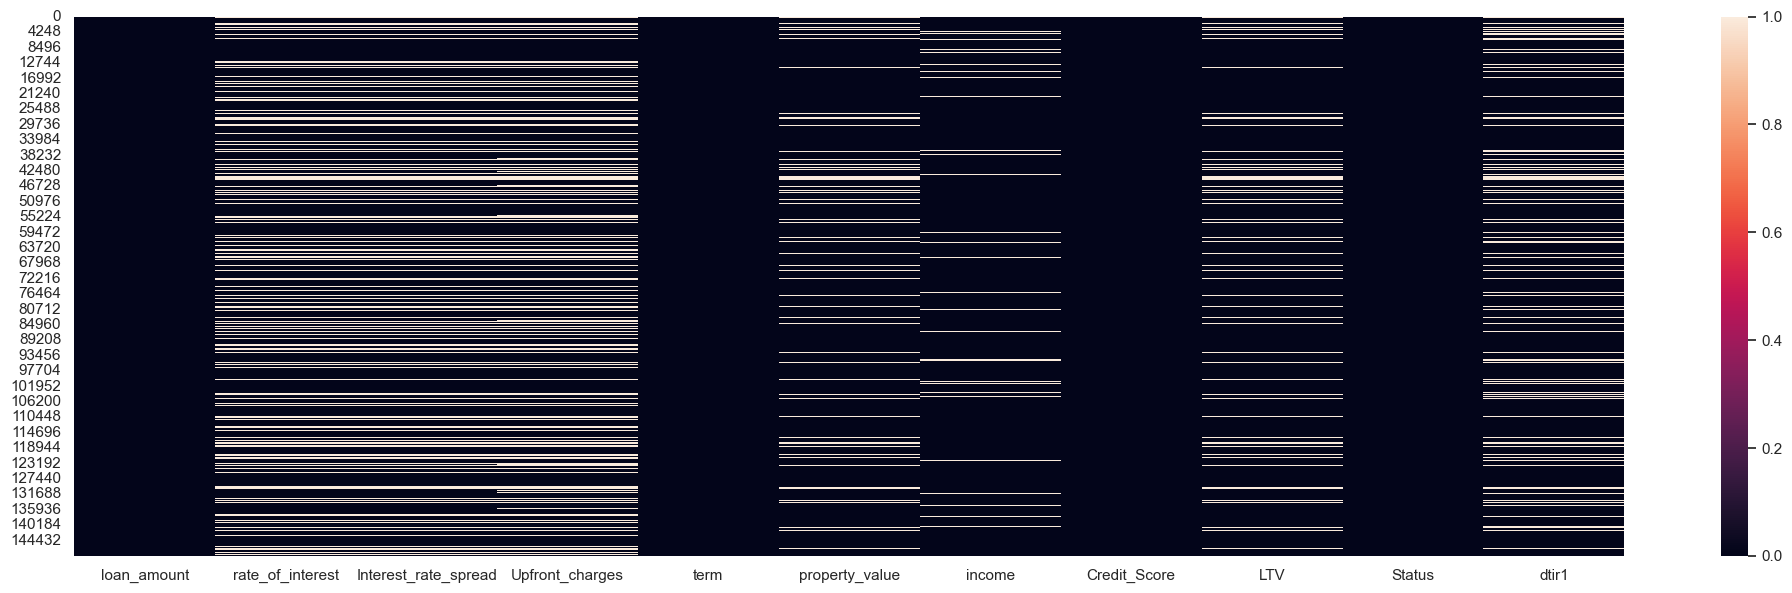

In [29]:
plt.figure(figsize=(25,7))
sns.heatmap(df[NumCols].isnull())
plt.show()

---

In [30]:
df

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,...,EXP,758,CIB,25-34,to_inst,98.73,south,direct,1,45.00
1,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,...,EXP,834,CIB,35-44,to_inst,80.02,south,direct,0,46.00
3,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,...,EXP,587,CIB,45-54,not_inst,69.38,North,direct,0,42.00
4,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,...,CRIF,602,EXP,25-34,not_inst,91.89,North,direct,0,39.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,436500,3.12,...,CIB,659,EXP,55-64,to_inst,71.79,south,direct,0,48.00
148666,cf,Male,nopre,type1,p1,l1,nopc,nob/c,586500,5.19,...,CIB,569,CIB,25-34,not_inst,74.43,south,direct,0,15.00
148667,cf,Male,nopre,type1,p4,l1,nopc,nob/c,446500,3.12,...,CIB,702,EXP,45-54,not_inst,61.33,North,direct,0,49.00
148668,cf,Female,nopre,type1,p4,l1,nopc,nob/c,196500,3.50,...,EXP,737,EXP,55-64,to_inst,70.68,North,direct,0,29.00


In [31]:
df[df['Status']==1].describe()

,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,36639.00,200.00,0.00,153.00,36624.00,21543.00,35400.00,36639.00,21543.00,36639.00,20329.00
mean,319275.18,4.35,NaN,1565.24,335.11,457786.01,6231.81,700.60,76.29,1.00,39.60
std,208576.81,0.50,NaN,2299.82,57.12,436255.03,7247.65,116.49,28.58,0.00,12.72
min,16500.00,3.12,NaN,0.00,96.00,8000.00,0.00,500.00,0.97,1.00,5.00
25%,176500.00,3.99,NaN,0.00,360.00,228000.00,3000.00,599.50,64.27,1.00,32.00
50%,276500.00,4.31,NaN,687.85,360.00,348000.00,4860.00,700.00,79.36,1.00,42.00
75%,416500.00,4.75,NaN,2310.75,360.00,558000.00,7620.00,803.00,90.95,1.00,49.00
max,3576500.00,5.50,NaN,15584.00,360.00,16508000.00,578580.00,900.00,2956.25,1.00,61.00


In [32]:
df[df['Status']==0].describe()


,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,112031.00,112031.00,112031.00,108875.00,112005.00,112029.00,104120.00,112031.00,112029.00,112031.00,104220.00
mean,334990.77,4.04,0.44,3227.33,335.14,505606.07,7204.01,699.52,72.06,0.00,37.37
std,174916.57,0.56,0.51,3251.67,58.82,342784.46,6201.34,115.67,41.77,0.00,10.03
min,26500.00,0.00,-3.64,0.00,96.00,8000.00,0.00,500.00,2.07,0.00,5.00
25%,206500.00,3.62,0.08,584.39,360.00,288000.00,4020.00,599.00,59.97,0.00,31.00
50%,306500.00,3.99,0.39,2600.00,360.00,428000.00,6000.00,699.00,74.50,0.00,38.00
75%,446500.00,4.38,0.78,4815.32,360.00,638000.00,8760.00,800.00,85.20,0.00,44.00
max,3006500.00,8.00,3.36,60000.00,360.00,9268000.00,377220.00,900.00,7831.25,0.00,61.00


In [33]:
newdf = pd.read_csv('data/Cleaned_loan_records.csv')

In [34]:
newdf

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,...,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1,has_Upfront_charges
0,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,4.30,...,758,CIB,25-34,to_inst,98.73,south,direct,1,45.00,0
1,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,4.01,...,552,EXP,55-64,to_inst,0.68,North,direct,1,19.81,0
2,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,...,834,CIB,35-44,to_inst,80.02,south,direct,0,46.00,1
3,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,...,587,CIB,45-54,not_inst,69.38,North,direct,0,42.00,0
4,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,...,602,EXP,25-34,not_inst,91.89,North,direct,0,39.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147752,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,436500,3.12,...,659,EXP,55-64,to_inst,71.79,south,direct,0,48.00,1
147753,cf,Male,nopre,type1,p1,l1,nopc,nob/c,586500,5.19,...,569,CIB,25-34,not_inst,74.43,south,direct,0,15.00,0
147754,cf,Male,nopre,type1,p4,l1,nopc,nob/c,446500,3.12,...,702,EXP,45-54,not_inst,61.33,North,direct,0,49.00,1
147755,cf,Female,nopre,type1,p4,l1,nopc,nob/c,196500,3.50,...,737,EXP,55-64,to_inst,70.68,North,direct,0,29.00,1


In [35]:
logDF= np.log1p(newdf[log_cols])
logDF['Status'] = newdf['Status']

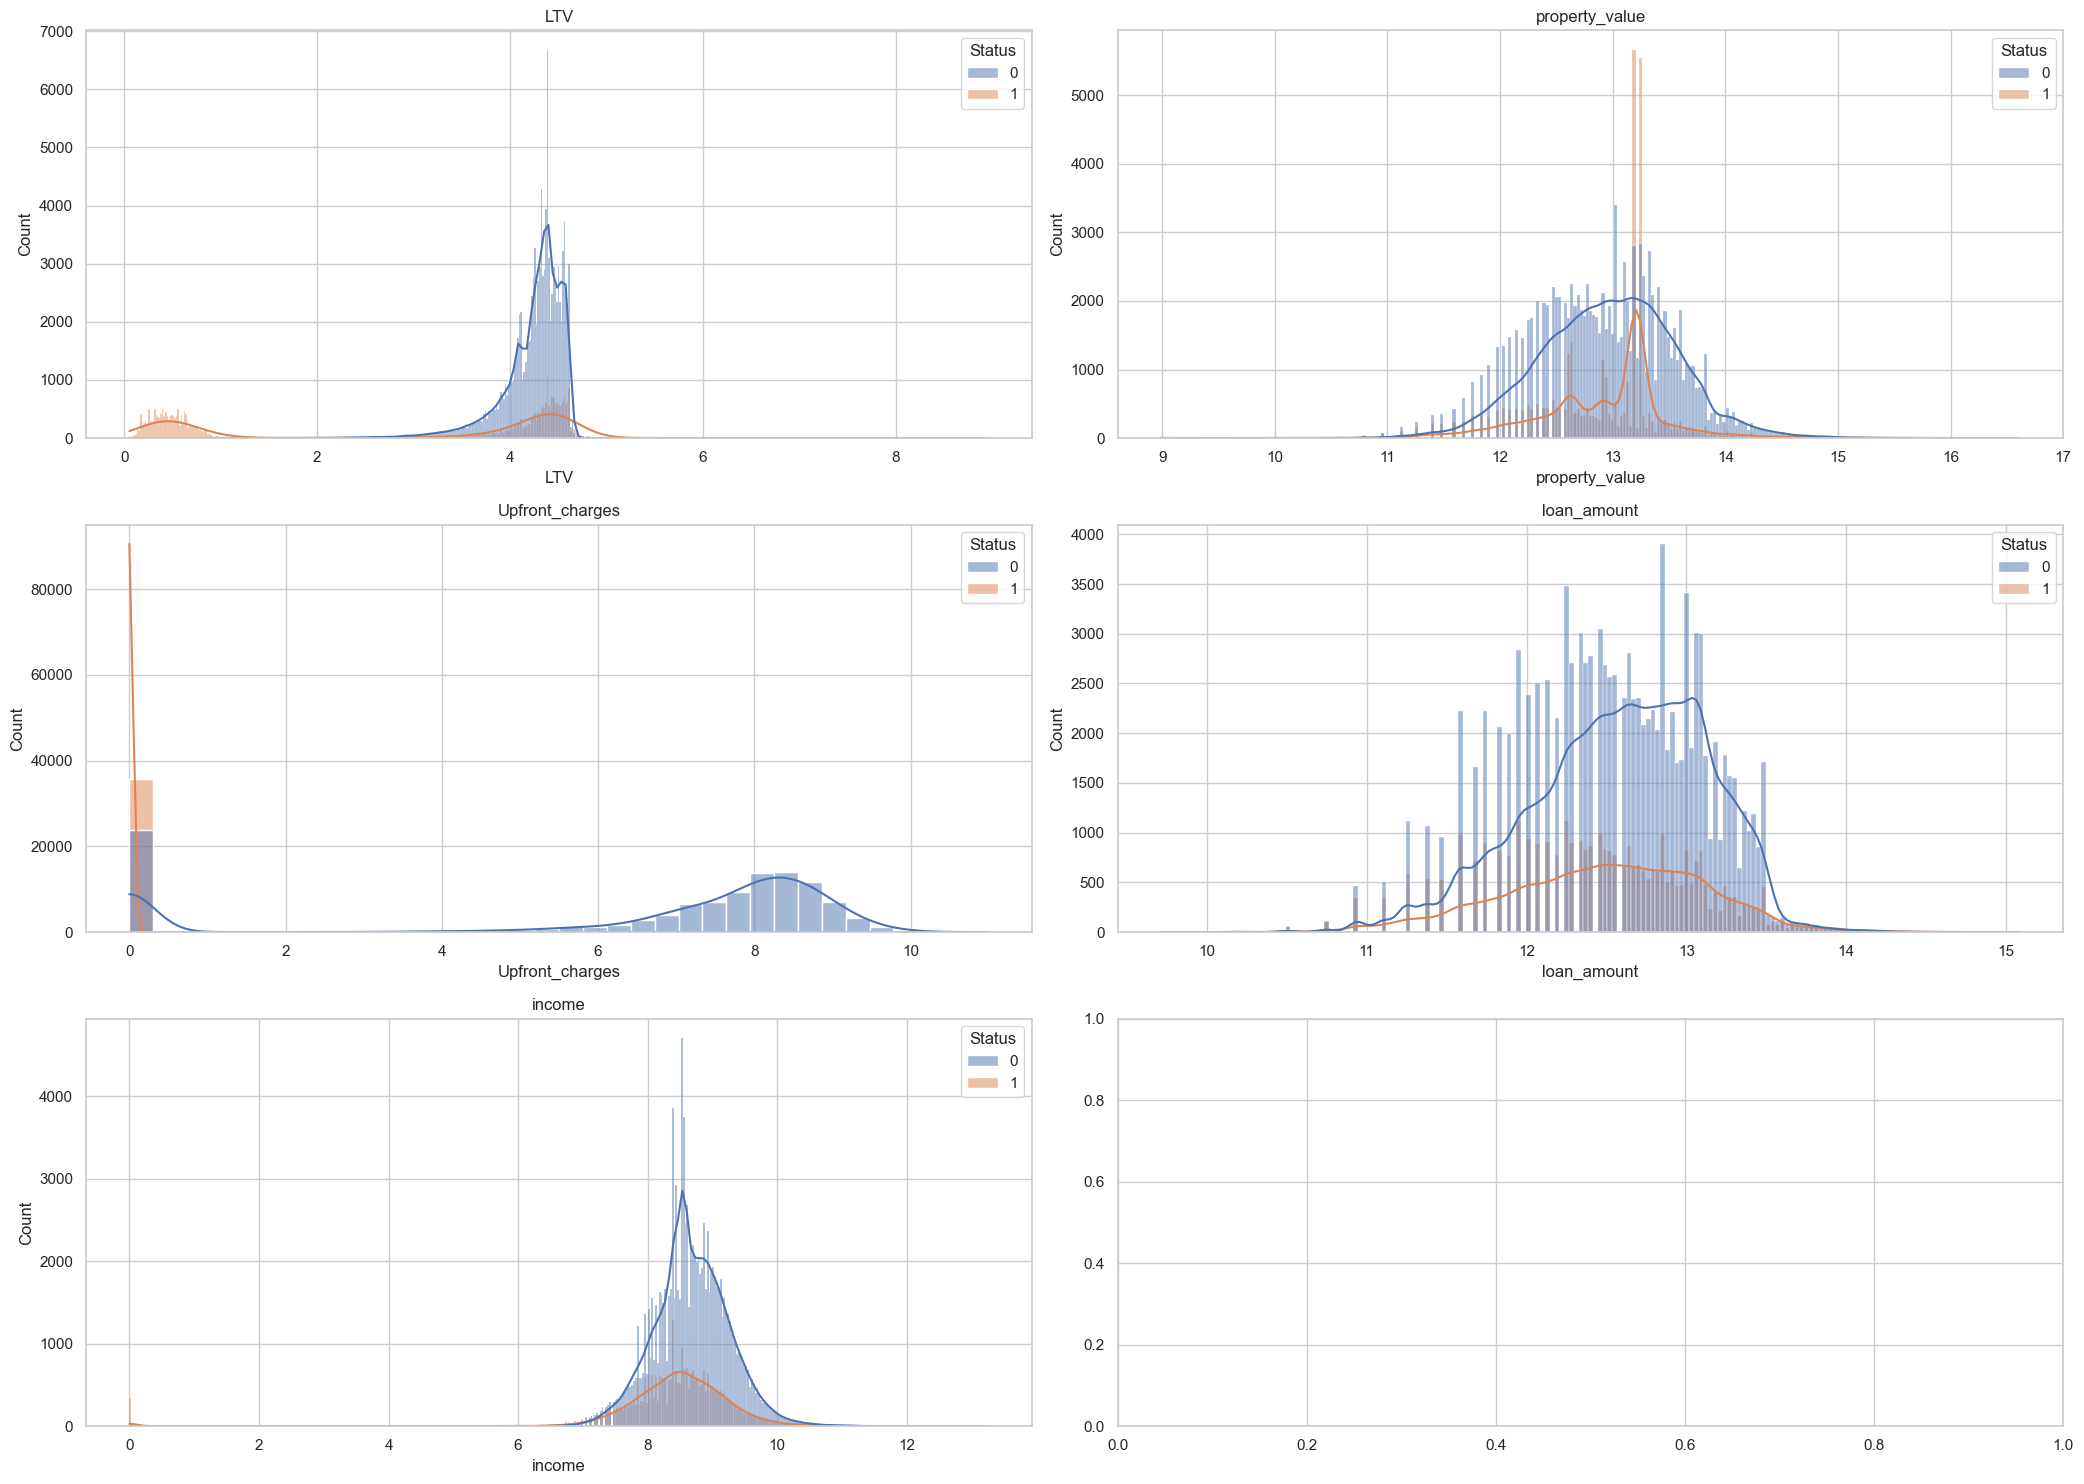

In [36]:
fig2,axes2 = plt.subplots(3,2,figsize=(21,15))
ax2 = axes2.flatten()

for i,col in enumerate(log_cols):
    sns.histplot(logDF,kde=True,x=col,ax=ax2[i],hue='Status').set_title(col)

plt.tight_layout()
plt.show()

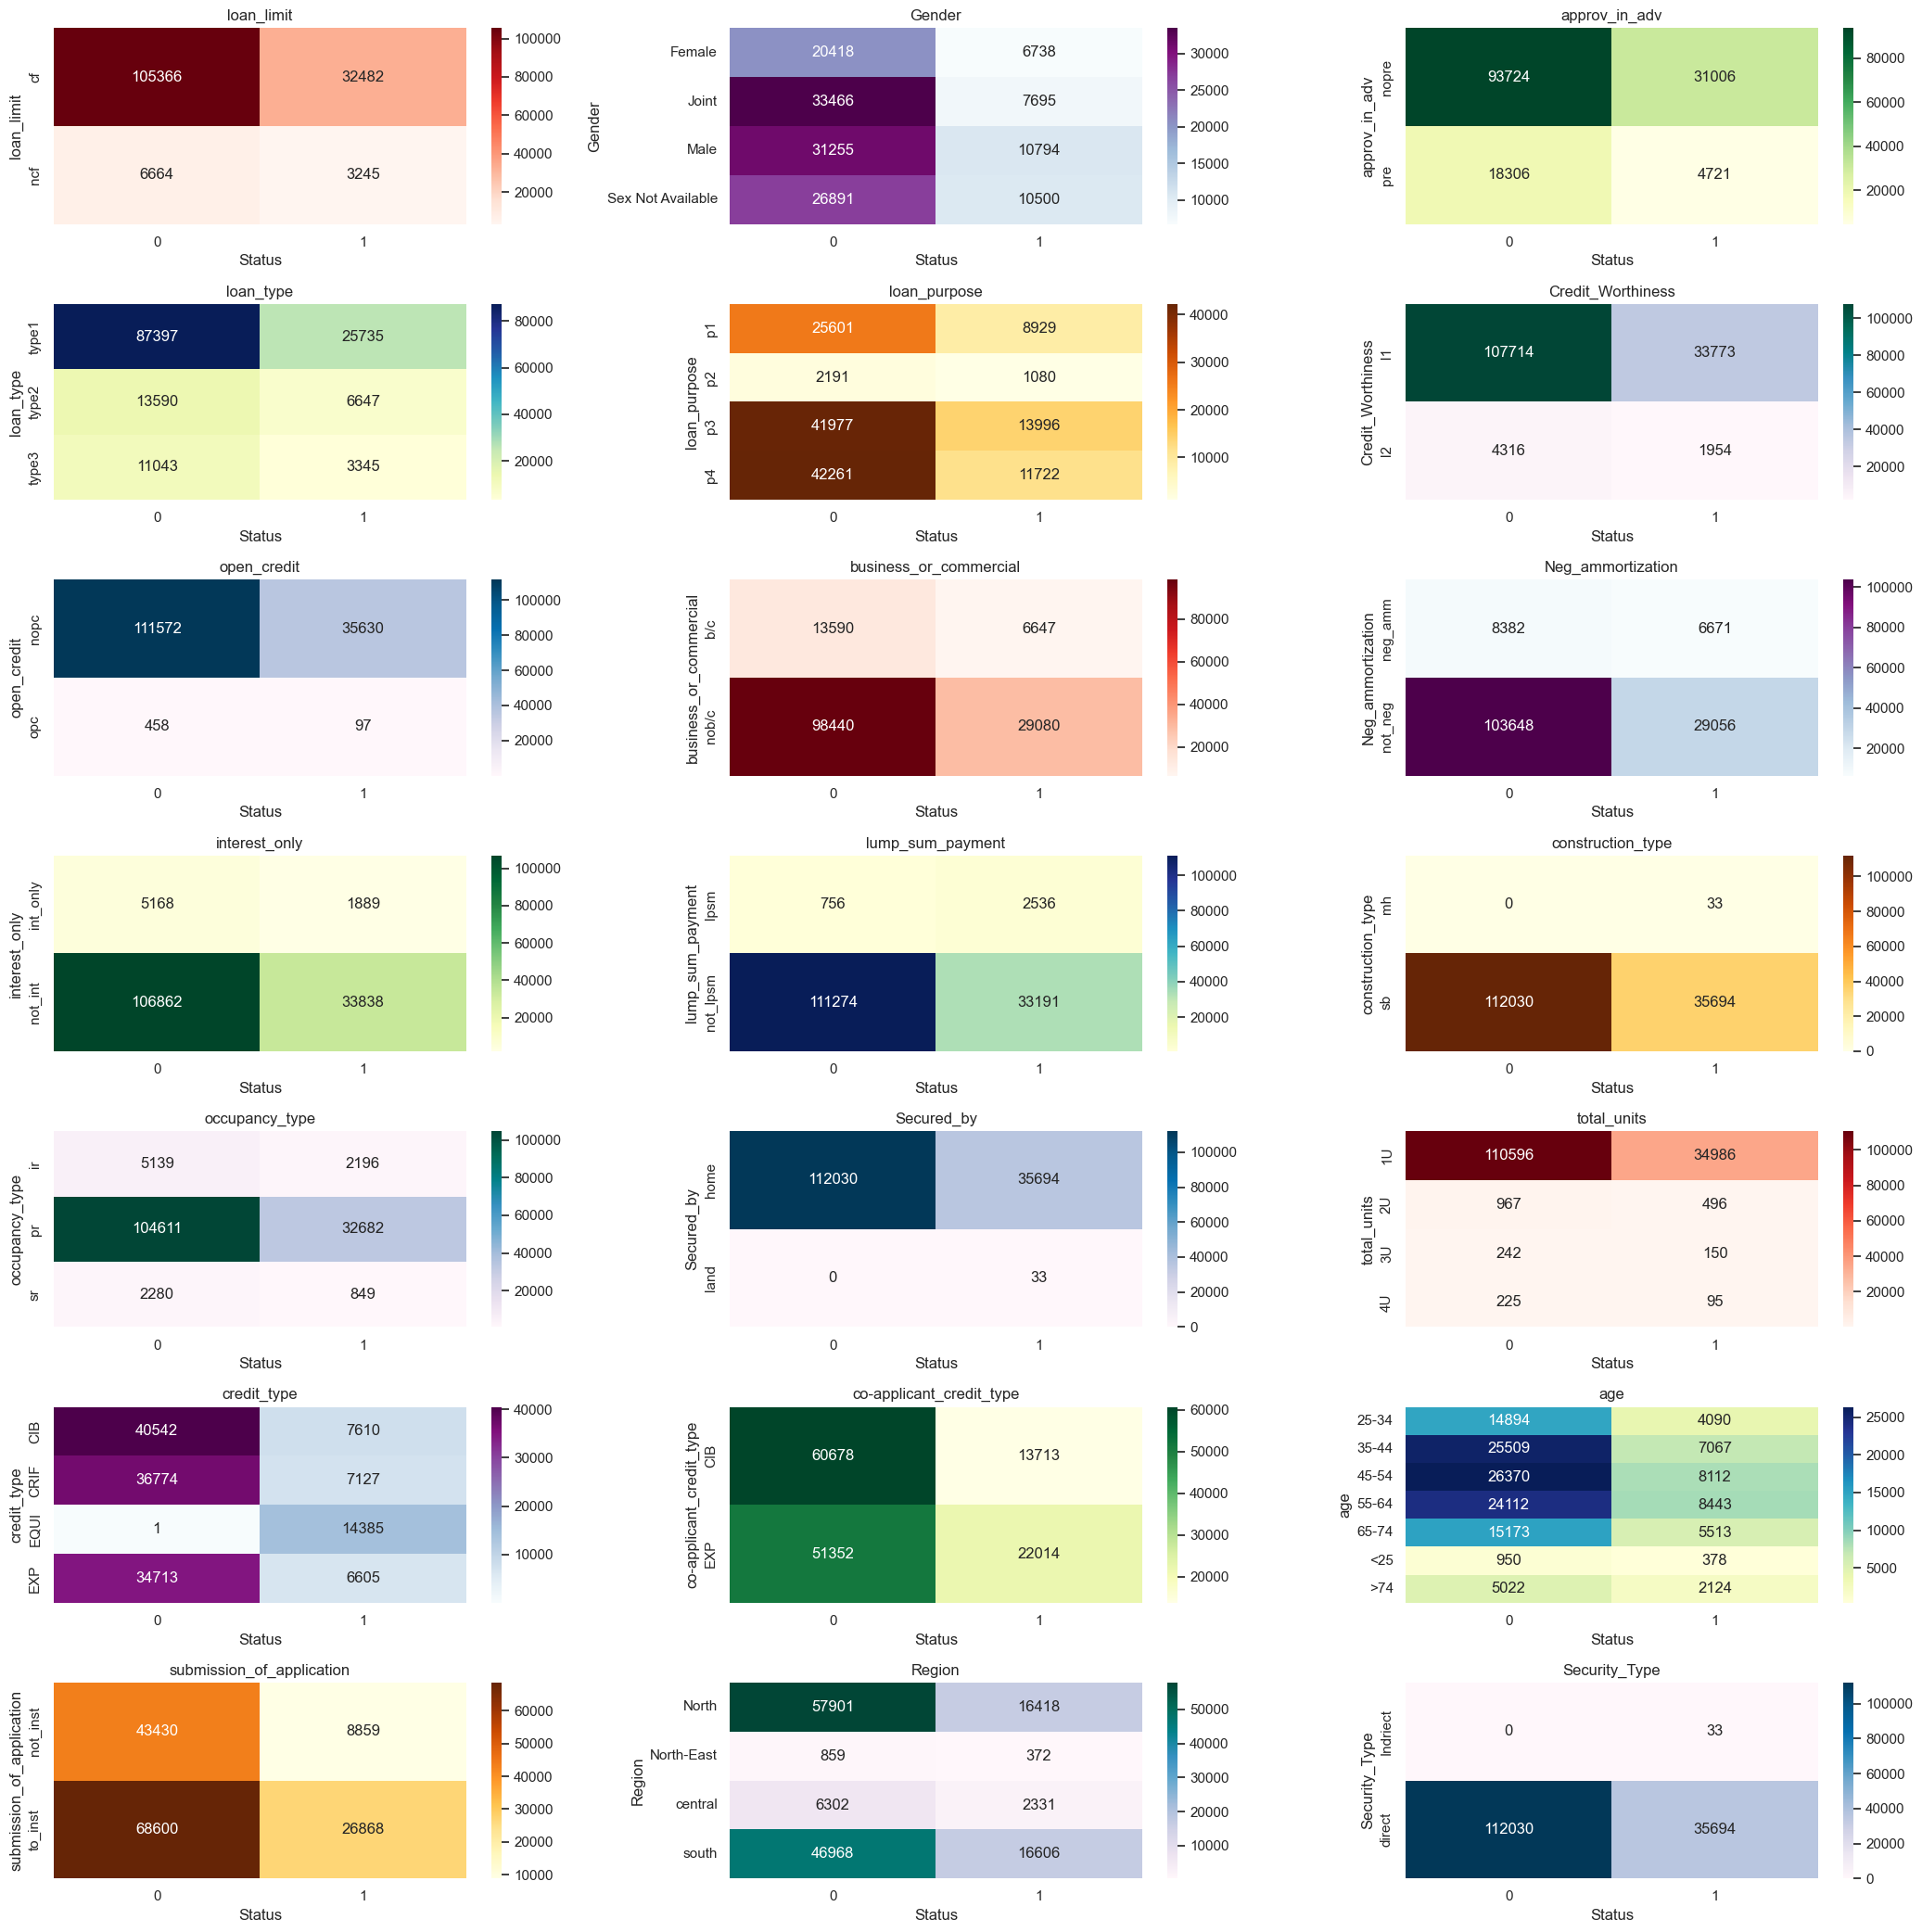

In [37]:
fig,axes = plt.subplots(7,3,figsize=(21,21))
ax = axes.flatten()
colors = ['Reds','BuPu','YlGn','YlGnBu','YlOrBr','PuBuGn','PuBu']
for i,col in enumerate(CatCols):
    sns.heatmap(pd.crosstab(columns=newdf['Status'],index=newdf[col]),annot=True,fmt="d",ax=ax[i],cmap=colors[i%7]).set_title(col)

plt.tight_layout()
plt.show()